# Porównywanie modeli 
Porównujemy 3 klasyfikatory: drzewo decyzyjne, regresję logistyczną i SVM.
Modele ładujemy z plików .pkl. Próg decyzyjny wyznaczamy tą samą metodą dla każdego modelu (tune_threshold na trainie). Główne kryterium: **zysk banku**.

# 1. Ładowanie danych i modeli


In [20]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from src.preprocessing import load_data, get_preprocessed_split
from src.metrics import calculate_profit, profit_summary, tune_threshold


In [21]:
X_train, X_test, y_train, y_test, salaries_train, salaries_test, preprocessor = get_preprocessed_split(load_data())
models = {
    "Drzewo decyzyjne": joblib.load("../models/decision_tree.pkl"),
    "Regresja logistyczna": joblib.load("../models/logistic_reg.pkl"),
    "SVM (RBF)": joblib.load("../models/svm.pkl")
}
print("Modele załadowane.")

Modele załadowane.


/home/blazejdelag/ml_lab/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Ewaluacja modeli

In [22]:
results = []
for name, model in models.items():
    train_scores = model.predict_proba(X_train)[:, 1]
    threshold, _ = tune_threshold(y_train.values, train_scores, salaries_train)

    test_scores = model.predict_proba(X_test)[:, 1]
    y_pred = (test_scores >= threshold).astype(int)

    profit = calculate_profit(y_test, y_pred, salaries_test)

    fpr, tpr, _ = roc_curve(y_test, test_scores)
    roc_auc = auc(fpr, tpr) 

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision = tp/(tp + fp) if (tp + fp) > 0 else 0
    recall = tp/(tp + fn) if (tp + fn) > 0 else 0
    f1 = 2*precision*recall / (precision + recall) if (precision + recall) > 0 else 0

    results.append({
        "name": name,
        "profit": profit,
        "threshold": threshold,
        "roc_auc": roc_auc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "fpr": fpr,
        "tpr": tpr
    })
    print(f"{name} | próg: {threshold:.3f} | zysk: {profit:.2f}")
    print(profit_summary(y_test, y_pred, salaries_test))

Drzewo decyzyjne | próg: 0.936 | zysk: 499096.51
Nasz model:                 499096.51 $
Zniżka dla wszystkich:      204746.39 $
Brak zniżek:                490167.43 $
Przewaga nad all_discount:  294350.12 $
Przewaga nad no_discount:     8929.08 $
{'model': np.float64(499096.51), 'all_discount': np.float64(204746.39), 'no_discount': np.float64(490167.43)}
Regresja logistyczna | próg: 0.656 | zysk: 490744.05
Nasz model:                 490744.05 $
Zniżka dla wszystkich:      204746.39 $
Brak zniżek:                490167.43 $
Przewaga nad all_discount:  285997.66 $
Przewaga nad no_discount:      576.62 $
{'model': np.float64(490744.05), 'all_discount': np.float64(204746.39), 'no_discount': np.float64(490167.43)}
SVM (RBF) | próg: 0.594 | zysk: 500325.95
Nasz model:                 500325.95 $
Zniżka dla wszystkich:      204746.39 $
Brak zniżek:                490167.43 $
Przewaga nad all_discount:  295579.56 $
Przewaga nad no_discount:    10158.52 $
{'model': np.float64(500325.95), 'al

## 3. Tabelka porównawcza

In [23]:
df_results = pd.DataFrame(results).drop(columns=["fpr", "tpr"])

no_discount = calculate_profit(y_test, np.zeros_like(y_test), salaries_test)
all_discount = calculate_profit(y_test, np.ones_like(y_test), salaries_test)

baselines = pd.DataFrame([
    {"name": "Brak zniżek", "profit": no_discount},
    {"name": "Zniżka dla wszystkich", "profit": all_discount}
])

df_full = pd.concat([df_results, baselines], ignore_index=True)
df_full

,name,profit,threshold,roc_auc,precision,recall,f1,tp,tn,fp,fn
0,Drzewo decyzyjne,499096.51,0.936293,0.848343,0.821622,0.372549,0.512648,152.0,1559.0,33.0,256.0
1,Regresja logistyczna,490744.05,0.656090,0.778962,0.729730,0.066176,0.121348,27.0,1582.0,10.0,381.0
2,SVM (RBF),500325.95,0.593804,0.836258,0.839196,0.409314,0.550247,167.0,1560.0,32.0,241.0
3,Brak zniżek,490167.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Zniżka dla wszystkich,204746.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Porównanie zysków

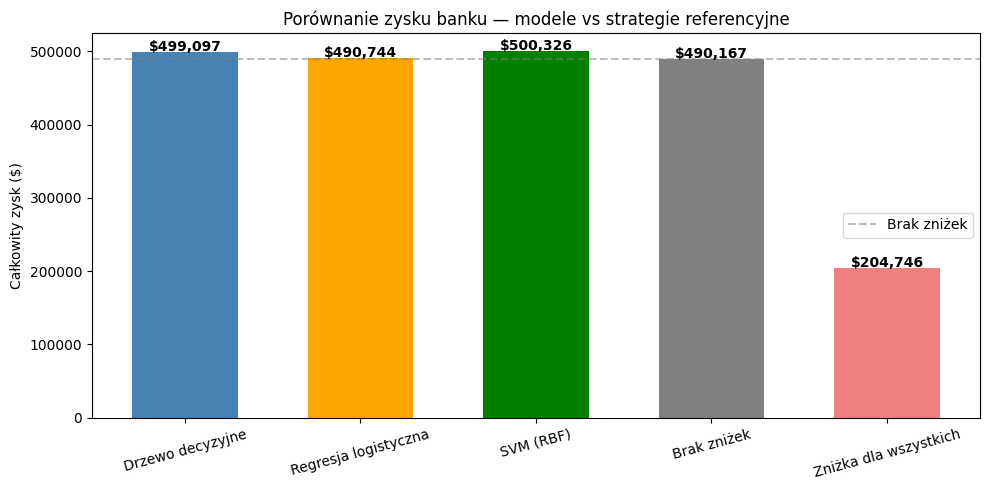

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

names = df_full["name"]
profits = df_full["profit"]
colors = ["steelblue", "orange", "green", "gray", "lightcoral"]

bars = ax.bar(names, profits, color=colors, width=0.6)

for bar, val in zip(bars, profits):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
            f"${val:,.0f}", ha="center", fontsize=10, fontweight="bold")

ax.axhline(no_discount, color="gray", linestyle="--", alpha=0.5, label="Brak zniżek")

ax.set_ylabel("Całkowity zysk ($)")
ax.set_title("Porównanie zysku banku — modele vs strategie referencyjne")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 5. Krzywe ROC

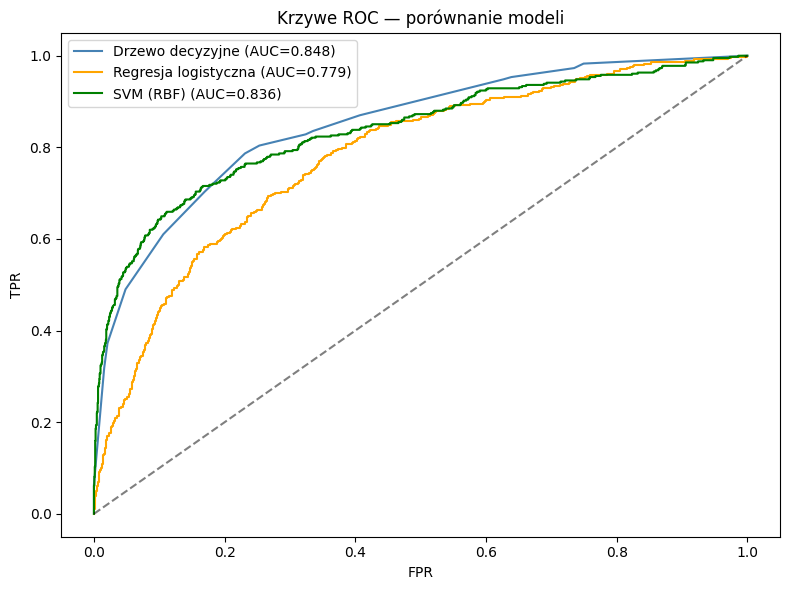

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ["steelblue", "orange", "green"]

for r, c in zip(results, colors_roc):
    ax.plot(r["fpr"], r["tpr"], color=c, label=f"{r['name']} (AUC={r['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("Krzywe ROC — porównanie modeli")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Macierze pomyłek

Drzewo decyzyjne 1559 33 256 152
Regresja logistyczna 1582 10 381 27
SVM (RBF) 1560 32 241 167


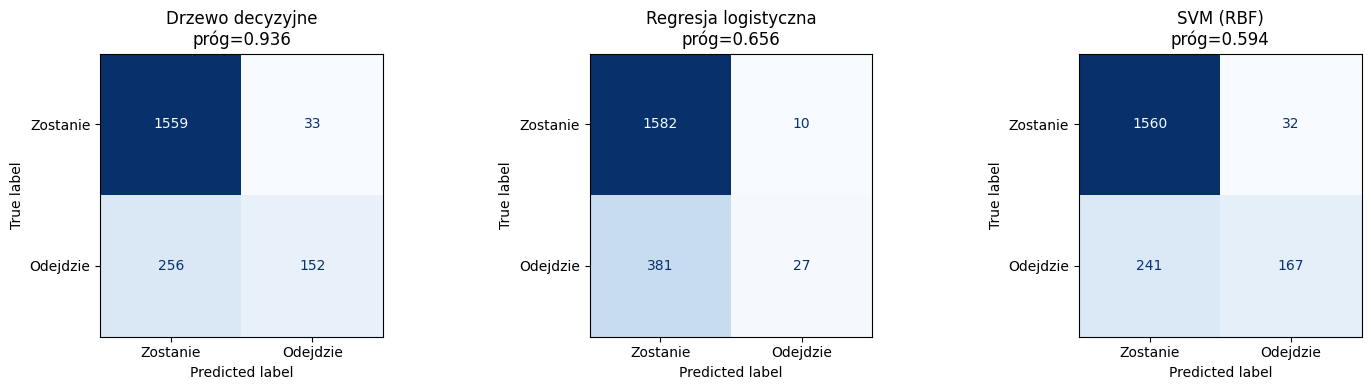

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for r in results:
    print(r["name"], r["tn"], r["fp"], r["fn"], r["tp"])

for ax, r in zip(axes, results):
    cm = np.array([[r["tn"], r["fp"]], [r["fn"], r["tp"]]])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Zostanie", "Odejdzie"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{r['name']}\npróg={r['threshold']:.3f}")

plt.tight_layout()
plt.show()

## 7. Wnioski

Najlepszym modelem pod kątem zysku jest SVM, który jako jedyny przebił barierę ponad 500 000$, co jednoczesnie świadczy o największej przewadze nad strategia brak zniżek, mimo, że wszystkie modele są lepsze od tej strategii to wygrywa SVM. Z kolei drzewo decyzyjne ma największy AUC, co jednak nie oznacza automatycznie największego zysku, bo zysk zależy od dobóru progu i asymetrii kosztów. Dla wszystkich 3 modeli progi optymalne są wysokie( większe niż 0.5). Modele konserwatywnie przyznają zniżki bo TN daje 0.3% salary, a TP tylko 0.1% - opłaca sie dawać zniżkę tylko wtedy kiedy model jest bardzo pewny churnu

REKOMENDACJA: SVM jako finalny model do wdrożenia, ponieważ uzyskalismy z nim najwięcej zysku. SVM najlepiej balansuje między łapaniem churnerów, a unikaniem nipotrzebnych zniżek.